In [1]:
# =============================================================================
# Cell 1: Imports and Spark Session (Using berdl_notebook_utils)
# =============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from pyspark.sql import functions as F, Window
from pyspark.sql.types import DoubleType
import math
from tqdm.auto import tqdm

# Import the Spark session utility as in the original notebook
from berdl_notebook_utils.setup_spark_session import get_spark_session

# Get the pre-configured Spark session
spark = get_spark_session()

sns.set_theme(style="whitegrid", palette="muted")
print("Spark session acquired from berdl_notebook_utils.")

Spark session acquired from berdl_notebook_utils.


In [2]:
# =============================================================================
# Cell 2: Haversine UDF for Spatial Distance Calculation
# =============================================================================
def haversine(lat1, lon1, lat2, lon2):
    if None in (lat1, lon1, lat2, lon2):
        return None
    R = 6371.0
    lat1_rad = math.radians(lat1)
    lat2_rad = math.radians(lat2)
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

haversine_udf = F.udf(haversine, DoubleType())

In [3]:
# =============================================================================
# Cell 3: Configure Table Paths
# =============================================================================
SOIL_DB = "arkinlab_microbeatlas"
KBASE_DB = "kbase_ke_pangenome"

SOIL_SAMPLE_TABLE = f"{SOIL_DB}.sample_metadata"
SOIL_ENRICHED_TABLE = f"{SOIL_DB}.enriched_metadata"
SOIL_GEE_TABLE = f"{SOIL_DB}.enriched_metadata_gee"
KBASE_COORDS_TABLE = f"{KBASE_DB}.alphaearth_embeddings_all_years"
KBASE_EGGNOG_TABLE = f"{KBASE_DB}.eggnog_mapper_annotations"
KBASE_GENE_TABLE = f"{KBASE_DB}.gene"

print("Table paths configured:")
print(f"  Soil sample: {SOIL_SAMPLE_TABLE}")
print(f"  Soil enriched: {SOIL_ENRICHED_TABLE}")
print(f"  Soil GEE: {SOIL_GEE_TABLE}")
print(f"  KBase coords: {KBASE_COORDS_TABLE}")
print(f"  KBase eggNOG: {KBASE_EGGNOG_TABLE}")
print(f"  KBase gene: {KBASE_GENE_TABLE}")

Table paths configured:
  Soil sample: arkinlab_microbeatlas.sample_metadata
  Soil enriched: arkinlab_microbeatlas.enriched_metadata
  Soil GEE: arkinlab_microbeatlas.enriched_metadata_gee
  KBase coords: kbase_ke_pangenome.alphaearth_embeddings_all_years
  KBase eggNOG: kbase_ke_pangenome.eggnog_mapper_annotations
  KBase gene: kbase_ke_pangenome.gene


In [4]:
# =============================================================================
# Cell 4: Load Soil Metal Data
# =============================================================================
# Load tables with error handling
try:
    df_sample = spark.table(SOIL_SAMPLE_TABLE)
    print(f"✓ Loaded {SOIL_SAMPLE_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {SOIL_SAMPLE_TABLE}: {e}")
    raise

try:
    df_enriched = spark.table(SOIL_ENRICHED_TABLE)
    print(f"✓ Loaded {SOIL_ENRICHED_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {SOIL_ENRICHED_TABLE}: {e}")
    raise

try:
    df_gee = spark.table(SOIL_GEE_TABLE)
    print(f"✓ Loaded {SOIL_GEE_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {SOIL_GEE_TABLE}: {e}")
    raise

# Deduplicate enriched and GEE tables
df_enriched = df_enriched.withColumn(
    "rn", F.row_number().over(Window.partitionBy("accession_id").orderBy("accession_id"))
).filter(F.col("rn") == 1).drop("rn")

df_gee = df_gee.withColumn(
    "rn", F.row_number().over(Window.partitionBy("SRS_Join_Key").orderBy("SRS_Join_Key"))
).filter(F.col("rn") == 1).drop("rn")

# Join all soil tables
df_soil_raw = (
    df_sample.alias("s")
    .join(df_enriched.alias("e"), F.col("s.sample_id") == F.col("e.accession_id"), "inner")
    .join(df_gee.alias("g"), F.col("s.SRS_Join_Key") == F.col("g.SRS_Join_Key"), "inner")
)

# Filter for soil samples with valid coordinates
df_soil_raw = df_soil_raw.filter(
    (F.col("s.SRS_Join_Key").isNotNull()) &
    (F.col("s.n_genes_by_counts").isNotNull()) &
    (F.col("s.Env_Level_1") == "soil")
).filter(
    F.col("g.LatitudeParsed").isNotNull() & F.col("g.LongitudeParsed").isNotNull()
)

# Define metal columns (list for multiple metals)
metal_columns = [
    "e.GeoROC_Rocks_georoc_Co_ppm", "e.GeoROC_Rocks_georoc_Cr_ppm",
    "e.GeoROC_Rocks_georoc_Cu_ppm", "e.GeoROC_Rocks_georoc_Ni_ppm",
    "e.GeoROC_Rocks_georoc_Zn_ppm", "e.GeoROC_Rocks_georoc_Pb_ppm",
    "e.GeoROC_Rocks_georoc_As_ppm", "e.GeoROC_Rocks_georoc_Cd_ppm",
    "e.GeoROC_Rocks_georoc_Hg_ppm"
]

# Create a clean soil metal DataFrame
df_soil_metal = df_soil_raw.select(
    F.col("s.sample_id"),
    F.col("g.LatitudeParsed").alias("lat"),
    F.col("g.LongitudeParsed").alias("lon"),
    F.col("g.olm_soil_ph_0cm_H2O").alias("ph"),
    *[F.col(c).cast("double").alias(c.split(".")[-1]) for c in metal_columns]
).cache()

print(f"Total soil samples with metal data: {df_soil_metal.count()}")
df_soil_metal.show(5, truncate=False)

✓ Loaded arkinlab_microbeatlas.sample_metadata
✓ Loaded arkinlab_microbeatlas.enriched_metadata
✓ Loaded arkinlab_microbeatlas.enriched_metadata_gee
Total soil samples with metal data: 51748
+----------------------+----------------+-----------------+-------+--------------------------+--------------------------+--------------------------+--------------------------+--------------------------+--------------------------+--------------------------+--------------------------+--------------------------+
|sample_id             |lat             |lon              |ph     |GeoROC_Rocks_georoc_Co_ppm|GeoROC_Rocks_georoc_Cr_ppm|GeoROC_Rocks_georoc_Cu_ppm|GeoROC_Rocks_georoc_Ni_ppm|GeoROC_Rocks_georoc_Zn_ppm|GeoROC_Rocks_georoc_Pb_ppm|GeoROC_Rocks_georoc_As_ppm|GeoROC_Rocks_georoc_Cd_ppm|GeoROC_Rocks_georoc_Hg_ppm|
+----------------------+----------------+-----------------+-------+--------------------------+--------------------------+--------------------------+--------------------------+------------

In [5]:
# =============================================================================
# Cell 5: Load KBase Genome Data with COG Annotations
# =============================================================================
# Coordinates
try:
    df_kbase_coords = spark.table(KBASE_COORDS_TABLE) \
        .select(
            F.col("genome_id"),
            F.expr("TRY_CAST(cleaned_lat AS DOUBLE)").alias("lat"),
            F.expr("TRY_CAST(cleaned_lon AS DOUBLE)").alias("lon")
        ).filter(F.col("lat").isNotNull())
    print(f"✓ Loaded {KBASE_COORDS_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {KBASE_COORDS_TABLE}: {e}")
    raise

# eggNOG annotations
try:
    df_eggnog = spark.table(KBASE_EGGNOG_TABLE) \
        .select(
            F.col("query_name").alias("gene_id"),
            F.col("COG_category")
        )
    print(f"✓ Loaded {KBASE_EGGNOG_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {KBASE_EGGNOG_TABLE}: {e}")
    raise

# Gene to genome mapping
try:
    df_gene_map = spark.table(KBASE_GENE_TABLE) \
        .select("gene_id", "genome_id")
    print(f"✓ Loaded {KBASE_GENE_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {KBASE_GENE_TABLE}: {e}")
    raise

# Aggregate COG counts per genome
df_genome_cog = df_gene_map.join(df_eggnog, "gene_id", "inner") \
    .groupBy("genome_id", "COG_category").count() \
    .groupBy("genome_id").pivot("COG_category").sum("count").fillna(0)

# Join with coordinates
df_kbase_cog = df_kbase_coords.join(df_genome_cog, "genome_id", "left").fillna(0)

print(f"KBase genomes with coordinates: {df_kbase_cog.count()}")
# Show only first few columns to avoid wide output
df_kbase_cog.select("genome_id", "lat", "lon", *df_kbase_cog.columns[3:6]).show(5, truncate=False)

✓ Loaded kbase_ke_pangenome.alphaearth_embeddings_all_years
✓ Loaded kbase_ke_pangenome.eggnog_mapper_annotations
✓ Loaded kbase_ke_pangenome.gene
KBase genomes with coordinates: 83286
+------------------+-----------+----------+---+---+---+
|genome_id         |lat        |lon       |-  |A  |ABO|
+------------------+-----------+----------+---+---+---+
|GB_GCA_019417585.1|35.68099174|139.769013|49 |0  |0  |
|GB_GCA_024698785.1|35.84      |50.9391   |71 |0  |0  |
|GB_GCA_022743185.1|-25.943357 |32.573694 |5  |0  |0  |
|GB_GCA_024640595.1|-36.545    |174.674139|53 |0  |0  |
|RS_GCF_018722605.1|61.067     |25.033    |185|1  |0  |
+------------------+-----------+----------+---+---+---+
only showing top 5 rows


In [6]:
# =============================================================================
# Cell 6: Spatial Join with Binning and Distance Filter
# =============================================================================
RADIUS_KM = 10.0

# Binning coordinates (0.1 degree ≈ 11 km at equator)
spark_soil_binned = df_soil_metal.withColumn("lat_bin", F.round("lat", 1)) \
                                 .withColumn("lon_bin", F.round("lon", 1))

spark_kbase_binned = df_kbase_cog.withColumn("lat_bin", F.round("lat", 1)) \
                                 .withColumn("lon_bin", F.round("lon", 1))

# Inner join on bins (Note: may miss pairs near bin boundaries)
joined = spark_soil_binned.alias("soil").join(
    spark_kbase_binned.alias("kb"),
    on=["lat_bin", "lon_bin"],
    how="inner"
)

# Apply Haversine distance filter
nearby = joined.withColumn(
    "distance_km",
    haversine_udf(
        F.col("soil.lat"), F.col("soil.lon"),
        F.col("kb.lat"), F.col("kb.lon")
    )
).filter(F.col("distance_km") <= RADIUS_KM).cache()

total_soil = df_soil_metal.count()
distinct_soil = nearby.select("soil.sample_id").distinct().count()
print(f"Soil samples with ≥1 genome within {RADIUS_KM} km: {distinct_soil} (out of {total_soil})")

Soil samples with ≥1 genome within 10.0 km: 7566 (out of 51748)


In [7]:
# =============================================================================
# Cell 7: Aggregate and Normalize COG Counts per Soil Sample
# =============================================================================
cog_columns = [c for c in df_genome_cog.columns if c != "genome_id"]
print(f"Number of COG categories: {len(cog_columns)}")

# Count nearby genomes per sample
df_genome_count = nearby.groupBy("soil.sample_id").agg(
    F.count("kb.genome_id").alias("num_nearby_genomes")
)

# Sum COG counts across nearby genomes
agg_exprs = [F.sum(F.col(f"kb.{c}")).alias(f"sum_{c}") for c in cog_columns]
df_cog_sum = nearby.groupBy("soil.sample_id").agg(*agg_exprs)

# Normalize by number of genomes (average COG count per genome)
norm_exprs = [(F.col(f"sum_{c}") / F.col("num_nearby_genomes")).alias(f"avg_{c}") for c in cog_columns]
df_cog_norm = df_cog_sum.join(df_genome_count, "sample_id").select("sample_id", "num_nearby_genomes", *norm_exprs)

# Join back to soil metal data
df_metal_cog = df_soil_metal.join(df_cog_norm, "sample_id", "left").fillna(0)

# Downsample for performance (first analysis only)
pdf_metal_cog = df_metal_cog.sample(fraction=0.3, seed=42).toPandas()
print(f"Downsampled dataset shape: {pdf_metal_cog.shape}")
pdf_metal_cog.head()

Number of COG categories: 435
Downsampled dataset shape: (15618, 449)


,sample_id,lat,lon,ph,GeoROC_Rocks_georoc_Co_ppm,GeoROC_Rocks_georoc_Cr_ppm,GeoROC_Rocks_georoc_Cu_ppm,GeoROC_Rocks_georoc_Ni_ppm,GeoROC_Rocks_georoc_Zn_ppm,GeoROC_Rocks_georoc_Pb_ppm,...,avg_TZ,avg_U,avg_UW,avg_UY,avg_UZ,avg_V,avg_VW,avg_W,avg_Y,avg_Z
0,SRR10089070.SRS5364427,27.142328,-81.35767,Unknown,65.4,0.0,316.6,187.1,1131.8,0.0,...,0.0,0.00,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
1,SRR10174653.SRS5428797,44.120000,-89.53000,Unknown,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
2,SRR10301170.SRS5534644,51.139528,10.35859,Unknown,61.2,0.0,0.0,0.0,0.0,0.0,...,0.0,18.75,0.0,0.0,0.0,24.125,0.0,0.0,0.0,0.0
3,SRR10312514.SRS5544707,72.392760,-77.52348,Unknown,40.0,337.0,160.0,77.0,97.0,0.0,...,0.0,0.00,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
4,SRR10454301.SRS5656435,46.729800,-117.18170,Unknown,0.0,271.0,87.0,117.0,83.0,5.0,...,0.0,0.00,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0


In [8]:
# =============================================================================
# Cell 8: Correlation Analysis for One Example Metal (Copper)
# =============================================================================
# For demonstration, we analyze copper; later we will analyze all metals.
METAL_COL = 'GeoROC_Rocks_georoc_Cu_ppm'
cog_avg_cols = [f"avg_{c}" for c in cog_columns]

corr_results = []
for cog_col in tqdm(cog_avg_cols, desc="Spearman correlations (first analysis)"):
    valid = pdf_metal_cog[[METAL_COL, cog_col]].dropna()
    if len(valid) < 5 or valid[cog_col].nunique() <= 1:
        continue
    corr, p = spearmanr(valid[METAL_COL], valid[cog_col])
    corr_results.append({
        'COG': cog_col.replace('avg_', ''),
        'correlation': corr,
        'p_value': p
    })

df_corr = pd.DataFrame(corr_results)
if len(df_corr) > 0:
    _, df_corr['p_adj_fdr'], _, _ = multipletests(df_corr['p_value'], method='fdr_bh')
    df_corr = df_corr.sort_values('p_adj_fdr')

sig_corr = df_corr[df_corr['p_adj_fdr'] < 0.05]
print(f"Significant COG categories (FDR < 0.05): {len(sig_corr)}")
sig_corr.head(10)

Spearman correlations (first analysis):   0%|          | 0/435 [00:00<?, ?it/s]

Significant COG categories (FDR < 0.05): 116


,COG,correlation,p_value,p_adj_fdr
9,BQ,-0.071164,5.384128e-19,1.243734e-16
91,FQ,-0.069135,5.167134e-18,5.968040e-16
86,FK,-0.060270,4.760140e-14,3.665308e-12
17,CF,-0.059373,1.120517e-13,6.470985e-12
11,CE,-0.058725,2.061501e-13,9.524136e-12
147,IU,-0.058427,2.724244e-13,1.048834e-11
221,QU,-0.057955,4.220553e-13,1.392782e-11
228,UW,-0.055439,4.117153e-12,1.188828e-10
48,DNZ,0.053299,2.645197e-11,6.789338e-10
199,NOU,-0.053036,3.308318e-11,7.642214e-10


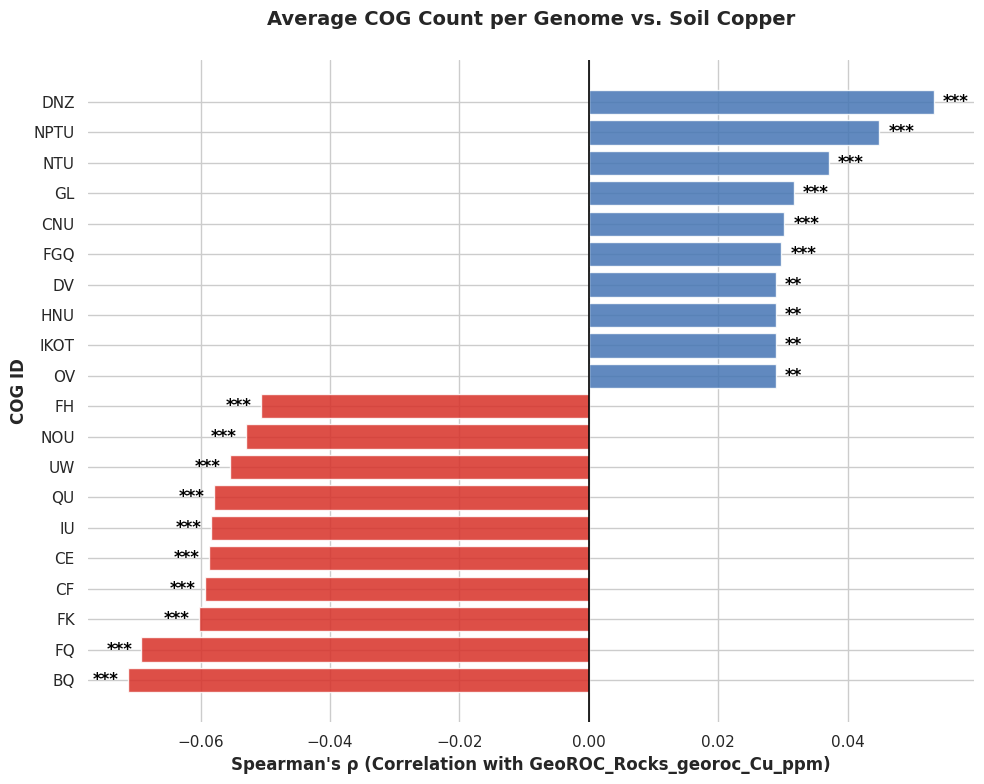

In [9]:
# =============================================================================
# Cell 9: Visualize Top Significant Correlations (First Analysis)
# =============================================================================
if len(sig_corr) > 0:
    top_pos = sig_corr[sig_corr['correlation'] > 0].nlargest(10, 'correlation')
    top_neg = sig_corr[sig_corr['correlation'] < 0].nsmallest(10, 'correlation')
    plot_df = pd.concat([top_pos, top_neg]).sort_values('correlation', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['#d73027' if r < 0 else '#4575b4' for r in plot_df['correlation']]
    bars = ax.barh(plot_df['COG'], plot_df['correlation'], color=colors, edgecolor='white', alpha=0.85)
    ax.set_xlabel(f"Spearman's ρ (Correlation with {METAL_COL})", fontweight='bold')
    ax.set_ylabel("COG ID", fontweight='bold')
    ax.set_title('Average COG Count per Genome vs. Soil Copper', pad=25, fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=1.2, linestyle='-')
    sns.despine(left=True, bottom=True)

    offset = plot_df['correlation'].abs().max() * 0.02
    for bar, p_adj in zip(bars, plot_df['p_adj_fdr']):
        width = bar.get_width()
        symbol = ''
        if p_adj < 0.001: symbol = '***'
        elif p_adj < 0.01: symbol = '**'
        elif p_adj < 0.05: symbol = '*'
        if symbol:
            x_pos = width - offset if width < 0 else width + offset
            ha = 'right' if width < 0 else 'left'
            ax.text(x_pos, bar.get_y() + bar.get_height()/2, symbol,
                    va='center', ha=ha, color='black', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No significant correlations after FDR correction.")

In [10]:
# =============================================================================
# Cell 10: Load GTDB Taxonomy for KBase Genomes
# =============================================================================
GTDB_TABLE = f"{KBASE_DB}.gtdb_taxonomy_r214v1"

try:
    df_gtdb = spark.table(GTDB_TABLE) \
        .select("genome_id", "domain", "phylum", "class", "order", "family", "genus", "species")
    print(f"✓ Loaded {GTDB_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {GTDB_TABLE}: {e}")
    raise

print(f"KBase genomes with GTDB taxonomy: {df_gtdb.count()}")
df_gtdb.show(5, truncate=False)

✓ Loaded kbase_ke_pangenome.gtdb_taxonomy_r214v1
KBase genomes with GTDB taxonomy: 293059
+------------------+-----------+-----------------+----------------------+-------------------+---------------------+--------------+-------------------------+
|genome_id         |domain     |phylum           |class                 |order              |family               |genus         |species                  |
+------------------+-----------+-----------------+----------------------+-------------------+---------------------+--------------+-------------------------+
|RS_GCF_020034805.1|d__Bacteria|p__Pseudomonadota|c__Gammaproteobacteria|o__Enterobacterales|f__Enterobacteriaceae|g__Escherichia|s__Escherichia fergusonii|
|RS_GCF_013812875.1|d__Bacteria|p__Pseudomonadota|c__Gammaproteobacteria|o__Enterobacterales|f__Enterobacteriaceae|g__Escherichia|s__Escherichia fergusonii|
|RS_GCF_019839545.1|d__Bacteria|p__Pseudomonadota|c__Gammaproteobacteria|o__Enterobacterales|f__Enterobacteriaceae|g__Escheri

In [11]:
# =============================================================================
# Cell 11: Load OTU Data and Aggregate to Order Level
# =============================================================================
OTU_TABLE = f"{SOIL_DB}.otu_counts_long"
OTU_METADATA_TABLE = f"{SOIL_DB}.otu_metadata"

try:
    df_otu = spark.table(OTU_TABLE)
    print(f"✓ Loaded {OTU_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {OTU_TABLE}: {e}")
    raise

try:
    df_otu_tax = spark.table(OTU_METADATA_TABLE)
    print(f"✓ Loaded {OTU_METADATA_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {OTU_METADATA_TABLE}: {e}")
    raise

# Parse taxonomy string into ranks
ranks = ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]
df_otu_tax = df_otu_tax.withColumn("tax_array", F.split(F.col("Tax"), ";"))
for i, rank in enumerate(ranks):
    df_otu_tax = df_otu_tax.withColumn(rank, F.try_element_at(F.col("tax_array"), F.lit(i+1)))
df_otu_tax = df_otu_tax.drop("tax_array")

# Join OTU counts with taxonomy
df_otu_full = df_otu.join(df_otu_tax.select("otu_id", "Order"), "otu_id", "inner")

# Aggregate abundance by Order per sample
df_order_abund = df_otu_full.groupBy("sample_id", "Order").agg(F.sum("count").alias("abundance"))

# Calculate relative abundance per sample
sample_totals = df_order_abund.groupBy("sample_id").agg(F.sum("abundance").alias("total"))
df_order_rel = df_order_abund.join(sample_totals, "sample_id") \
    .withColumn("rel_abundance", F.col("abundance") / F.col("total")) \
    .select("sample_id", "Order", "rel_abundance")

print(f"Order-level relative abundance data: {df_order_rel.count()} rows")
df_order_rel.show(5, truncate=False)

✓ Loaded arkinlab_microbeatlas.otu_counts_long
✓ Loaded arkinlab_microbeatlas.otu_metadata
Order-level relative abundance data: 27121193 rows
+-------------------+---------------+--------------------+
|sample_id          |Order          |rel_abundance       |
+-------------------+---------------+--------------------+
|DRR000802.DRS000505|NULL           |0.868033931064104   |
|DRR000802.DRS000505|Pirellulales   |0.002147535702781059|
|DRR000802.DRS000505|Oscillatoriales|0.003006549983893482|
|DRR000802.DRS000505|Tissierellales |4.295071405562117E-4|
|DRR000802.DRS000505|Cellvibrionales|3.221303554171588E-4|
+-------------------+---------------+--------------------+
only showing top 5 rows


In [12]:
# =============================================================================
# Cell 12: Pre‑aggregate COG Profiles at Order Level (Avoids Explosive Join)
# =============================================================================
# Clean Order names (remove 'o__' prefix, lowercase)
def clean_taxon(col):
    return F.lower(F.regexp_replace(F.col(col), "^[a-z]__", ""))

df_order_rel_clean = df_order_rel.withColumn("order_clean", clean_taxon("Order"))
df_gtdb_clean = df_gtdb.withColumn("order_clean", clean_taxon("order"))

# Join COG counts with GTDB order
df_genome_cog_order = df_genome_cog.join(df_gtdb_clean, "genome_id", "inner")
print(f"Genomes with Order-level taxonomy and COG data: {df_genome_cog_order.count()}")

# CRITICAL FIX: Pre‑aggregate total COG counts per Order instead of joining at genome level
# This avoids the 37 billion row explosion.
cog_columns_list = [c for c in df_genome_cog.columns if c != "genome_id"]

# Sum COG counts across all genomes in each Order
order_cog_profile = df_genome_cog_order.groupBy("order_clean").agg(
    *[F.sum(c).alias(f"order_total_{c}") for c in cog_columns_list]
)

# Join this aggregated profile to sample‑order relative abundances
joined_tax = df_order_rel_clean.alias("soil").join(
    order_cog_profile.alias("kb"),
    on="order_clean",
    how="inner"
)

print(f"Join result rows (should equal number of sample‑order pairs): {joined_tax.count()}")
joined_tax.show(5, truncate=False)

Genomes with Order-level taxonomy and COG data: 271760
Join result rows (should equal number of sample‑order pairs): 15934561
+--------------+-------------------+--------------+---------------------+-------------+-------------+---------------+---------------+--------------+---------------+----------------+---------------+---------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+--------------+---------------+-----------------+--------------+--------------+---------------+--------------+--------------+-------------+--------------+---------------+---------------+--------------+---------------+---------------+----------------+---------------+----------------+---------------+---------------+--------------+---------------+--------------+---------------+---------------+--------------+---------------+-----------------+---------------+---------------+---------------+--------------+---------------+--------------+------

In [13]:
# =============================================================================
# Cell 13: Compute Abundance‑Weighted Community COG Profiles per Sample
# =============================================================================
# Weighted sum: rel_abundance * order_total_COG, aggregated per sample
weighted_exprs = [
    F.sum(F.col("soil.rel_abundance") * F.col(f"kb.order_total_{c}")).alias(f"weighted_{c}")
    for c in cog_columns_list
]

df_community_cog = joined_tax.groupBy("soil.sample_id").agg(*weighted_exprs)

# Join with soil metal data
df_metal_community = df_soil_metal.join(df_community_cog, "sample_id", "left").fillna(0)
print(f"Community-weighted DataFrame shape: {df_metal_community.count()} rows, {len(df_metal_community.columns)} columns")

Community-weighted DataFrame shape: 51748 rows, 448 columns


In [14]:
# =============================================================================
# Cell 14: Correlation Analysis for All Metals (Community‑Weighted)
# =============================================================================
# List of metals to analyze
metal_cols = [
    'GeoROC_Rocks_georoc_Co_ppm', 'GeoROC_Rocks_georoc_Cr_ppm',
    'GeoROC_Rocks_georoc_Cu_ppm', 'GeoROC_Rocks_georoc_Ni_ppm',
    'GeoROC_Rocks_georoc_Zn_ppm', 'GeoROC_Rocks_georoc_Pb_ppm',
    'GeoROC_Rocks_georoc_As_ppm', 'GeoROC_Rocks_georoc_Cd_ppm',
    'GeoROC_Rocks_georoc_Hg_ppm'
]

weighted_cols = [f"weighted_{c}" for c in cog_columns_list]

# Temporarily disable ANSI mode to avoid divide‑by‑zero issues in correlation
spark.conf.set("spark.sql.ansi.enabled", "false")

# Create a temporary view for SQL correlations
df_metal_community.createOrReplaceTempView("comm")

all_metal_results = []

for metal in metal_cols:
    # Build SQL correlation expressions
    select_parts = [f"corr(`{metal}`, `{c}`) AS `{c}`" for c in weighted_cols]
    query = f"SELECT {', '.join(select_parts)} FROM comm"
    df_corr_spark = spark.sql(query)

    # Convert to pandas (1 row × N columns)
    pdf_corrs = df_corr_spark.toPandas().T.reset_index()
    pdf_corrs.columns = ["COG_category", "correlation"]
    pdf_corrs['metal'] = metal
    all_metal_results.append(pdf_corrs)

# Combine all metals
df_all_corrs = pd.concat(all_metal_results, ignore_index=True)
df_all_corrs.head()

,COG_category,correlation,metal
0,weighted_-,-0.011312,GeoROC_Rocks_georoc_Co_ppm
1,weighted_A,-0.010222,GeoROC_Rocks_georoc_Co_ppm
2,weighted_ABO,-0.002090,GeoROC_Rocks_georoc_Co_ppm
3,weighted_ACE,NaN,GeoROC_Rocks_georoc_Co_ppm
4,weighted_AD,NaN,GeoROC_Rocks_georoc_Co_ppm


In [15]:
# =============================================================================
# Cell 15: Statistical Significance with FDR Correction (Per Metal)
# =============================================================================
# For each metal, compute p‑values using Spearman (requires pandas DataFrame)
# We'll collect the community‑weighted data to pandas (it's small enough: ~50k rows × 447 cols)
print("Collecting community‑weighted DataFrame to pandas...")
pdf_community = df_metal_community.toPandas()
print(f"Collected shape: {pdf_community.shape}")

# List of weighted COG columns
weighted_cog_cols = [c for c in pdf_community.columns if c.startswith('weighted_')]

# Store significant results across all metals
all_sig_results = []

for metal in tqdm(metal_cols, desc="Processing metals"):
    metal_results = []
    for cog_col in weighted_cog_cols:
        valid = pdf_community[[metal, cog_col]].dropna()
        if len(valid) < 5 or valid[cog_col].nunique() <= 1:
            continue
        r, p = spearmanr(valid[metal], valid[cog_col])
        metal_results.append({
            'metal': metal,
            'COG': cog_col.replace('weighted_', ''),
            'spearman_r': r,
            'p_value': p
        })
    df_metal = pd.DataFrame(metal_results)
    if len(df_metal) > 0:
        _, p_adj_fdr, _, _ = multipletests(df_metal['p_value'], method='fdr_bh')
        df_metal['p_adj_fdr'] = p_adj_fdr
        sig = df_metal[df_metal['p_adj_fdr'] < 0.05]
        all_sig_results.append(sig)

df_all_sig = pd.concat(all_sig_results, ignore_index=True) if all_sig_results else pd.DataFrame()
print(f"Total significant associations across all metals: {len(df_all_sig)}")

Collected shape: (51748, 448)


Processing metals:   0%|          | 0/9 [00:00<?, ?it/s]

Total significant associations across all metals: 2355


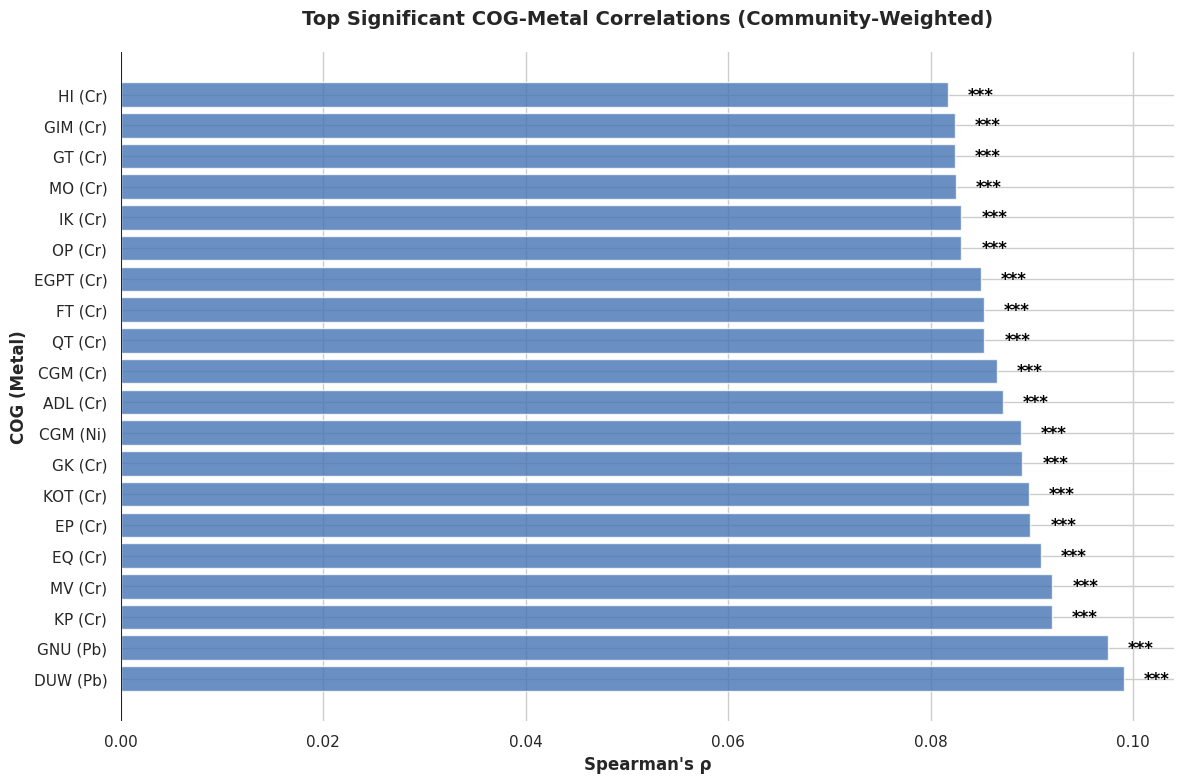

In [16]:
# =============================================================================
# Cell 16: Visualize Top Significant Correlations (All Metals)
# =============================================================================
if len(df_all_sig) > 0:
    # For clarity, show top associations per metal (here we show the most significant overall)
    top_overall = df_all_sig.sort_values('p_adj_fdr').head(20)

    fig, ax = plt.subplots(figsize=(12, 8))
    # Create a combined label for y‑axis
    top_overall['label'] = top_overall['COG'] + ' (' + top_overall['metal'].str.replace('GeoROC_Rocks_georoc_', '').str.replace('_ppm', '') + ')'
    colors = ['#d73027' if r < 0 else '#4575b4' for r in top_overall['spearman_r']]
    bars = ax.barh(top_overall['label'], top_overall['spearman_r'], color=colors, edgecolor='white', alpha=0.8)
    ax.set_xlabel("Spearman's ρ", fontweight='bold')
    ax.set_ylabel("COG (Metal)", fontweight='bold')
    ax.set_title('Top Significant COG‑Metal Correlations (Community‑Weighted)', pad=20, fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=1.2, linestyle='-')
    sns.despine(left=True, bottom=True)

    offset = top_overall['spearman_r'].abs().max() * 0.02
    for bar, p_adj in zip(bars, top_overall['p_adj_fdr']):
        width = bar.get_width()
        symbol = ''
        if p_adj < 0.001: symbol = '***'
        elif p_adj < 0.01: symbol = '**'
        elif p_adj < 0.05: symbol = '*'
        if symbol:
            x_pos = width - offset if width < 0 else width + offset
            ha = 'right' if width < 0 else 'left'
            ax.text(x_pos, bar.get_y() + bar.get_height()/2, symbol,
                    va='center', ha=ha, color='black', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No significant community‑weighted correlations after FDR correction.")

In [20]:
# =============================================================================
# Cell 17: Translate COG Categories to Functional Descriptions
# =============================================================================
cog_mapping = {
    'J': 'Translation, ribosomal structure and biogenesis',
    'A': 'RNA processing and modification', 'K': 'Transcription',
    'L': 'Replication, recombination and repair', 'B': 'Chromatin structure and dynamics',
    'D': 'Cell cycle control, cell division, chromosome partitioning',
    'Y': 'Nuclear structure', 'V': 'Defense mechanisms', 'T': 'Signal transduction mechanisms',
    'M': 'Cell wall/membrane/envelope biogenesis', 'N': 'Cell motility', 'Z': 'Cytoskeleton',
    'W': 'Extracellular structures', 'U': 'Intracellular trafficking, secretion, and vesicular transport',
    'O': 'Posttranslational modification, protein turnover, chaperones',
    'X': 'Mobilome: prophages, transposons', 'C': 'Energy production and conversion',
    'G': 'Carbohydrate transport and metabolism', 'E': 'Amino acid transport and metabolism',
    'F': 'Nucleotide transport and metabolism', 'H': 'Coenzyme transport and metabolism',
    'I': 'Lipid transport and metabolism', 'P': 'Inorganic ion transport and metabolism',
    'Q': 'Secondary metabolites biosynthesis, transport and catabolism',
    'R': 'General function only', 'S': 'Function unknown'
}

def translate_cog_str(cog_str):
    clean_str = str(cog_str).replace('avg_', '').replace('weighted_', '').strip()
    if not clean_str or clean_str in ['-', 'nan', 'None']:
        return "No category assigned"
    descs = [f"- {cog_mapping[char]}" for char in clean_str if char in cog_mapping]
    return "\n  ".join(descs) if descs else "No valid COG letters found"

# Show translated top results
if len(df_all_sig) > 0:
    top_show = df_all_sig.sort_values('p_adj_fdr').head(20)
    print(f"{'COG':<8} | {'Metal':<8} | {'ρ':<8} | {'FDR p‑value':<12} | Functional Description")
    print("=" * 100)
    for _, row in top_show.iterrows():
        metal_short = row['metal'].replace('GeoROC_Rocks_georoc_', '').replace('_ppm', '')
        desc = translate_cog_str(row['COG'])
        first_line = desc.split('\n')[0] if '\n' in desc else desc
        print(f"{row['COG']:<8} | {metal_short:<8} | {row['spearman_r']:+.4f}  | {row['p_adj_fdr']:<12.2e} | {first_line}")
        for extra in desc.split('\n')[1:]:
            print(f"{'':<8} | {'':<8} | {'':<8} | {'':<12} | {extra}")
        print("-" * 100)

COG      | Metal    | ρ        | FDR p‑value  | Functional Description
DUW      | Pb       | +0.0991  | 1.87e-110    | - Cell cycle control, cell division, chromosome partitioning
         |          |          |              |   - Intracellular trafficking, secretion, and vesicular transport
         |          |          |              |   - Extracellular structures
----------------------------------------------------------------------------------------------------
GNU      | Pb       | +0.0975  | 2.82e-107    | - Carbohydrate transport and metabolism
         |          |          |              |   - Cell motility
         |          |          |              |   - Intracellular trafficking, secretion, and vesicular transport
----------------------------------------------------------------------------------------------------
KP       | Cr       | +0.0920  | 2.49e-95     | - Transcription
         |          |          |              |   - Inorganic ion transport and metabolism
----

In [24]:
df_all_sig['abs_r'] = df_all_sig['spearman_r'].abs()
df_all_sig.sort_values('abs_r', ascending=False).head(40)

,metal,COG,spearman_r,p_value,p_adj_fdr,abs_r
1530,GeoROC_Rocks_georoc_Pb_ppm,DUW,0.099088,4.770099e-113,1.865109e-110,0.099088
1622,GeoROC_Rocks_georoc_Pb_ppm,GNU,0.097531,1.441409e-109,2.817954e-107,0.097531
569,GeoROC_Rocks_georoc_Cr_ppm,MV,0.092038,9.776991e-98,2.492147e-95,0.092038
531,GeoROC_Rocks_georoc_Cr_ppm,KP,0.091983,1.274756e-97,2.492147e-95,0.091983
404,GeoROC_Rocks_georoc_Cr_ppm,EQ,0.090871,2.601962e-95,3.391224e-93,0.090871
401,GeoROC_Rocks_georoc_Cr_ppm,EP,0.089867,2.988137e-93,2.920904e-91,0.089867
530,GeoROC_Rocks_georoc_Cr_ppm,KOT,0.089682,7.110322e-93,5.560272e-91,0.089682
440,GeoROC_Rocks_georoc_Cr_ppm,GK,0.089063,1.285830e-91,8.379326e-90,0.089063
879,GeoROC_Rocks_georoc_Ni_ppm,CGM,0.088931,2.368655e-91,9.261443e-89,0.088931
256,GeoROC_Rocks_georoc_Cr_ppm,ADL,0.087166,8.009877e-88,4.474088e-86,0.087166


In [18]:
# =============================================================================
# Cell 18: Limitations and Interpretation
# =============================================================================
print("""
===============================================================================
LIMITATIONS OF THIS ANALYSIS
===============================================================================

1. 16S rRNA vs. Metagenomic Data Linkage
   - The OTU data derives from 16S rRNA amplicon sequencing, which provides
     taxonomic composition but not direct functional gene content.
   - We link 16S‑based order abundances to COG profiles obtained from
     metagenome‑assembled genomes (MAGs) and reference genomes of the same
     order. This assumes that functional gene content is conserved at the
     order level, which may not hold for all functions.

2. Spatial Binning Artifacts
   - The spatial join uses 0.1° bins (~11 km) for efficiency. Genomes just
     across bin boundaries from a soil sample are excluded, potentially
     underestimating local functional gene presence.

3. Correlation vs. Causation
   - All reported associations are correlative. Confounding variables
     (e.g., soil pH, organic matter, climate, co‑occurring pollutants) are
     not controlled for. Multivariate approaches (e.g., partial correlation,
     RDA) would be needed to disentangle direct metal effects.

4. Effect Sizes
   - Many significant correlations have small |ρ| (<0.1). While statistically
     robust, their biological significance may be limited. Functional shifts
     might be subtle or mediated by other community changes.

5. Genome Completeness and Contamination
   - The KBase genomes vary in quality (completeness, contamination). COG
     counts are not normalized by genome size or quality, which may
     introduce noise.

6. Multiple Metal Interactions
   - Metals often co‑occur; here we analyze each metal independently.
     Future work should consider multivariate metal profiles.

7. Generalizability
   - This analysis is based on a specific set of soil samples and publicly
     available genomes. Results may not generalize to other ecosystems or
     genomic databases.

Despite these limitations, the notebook provides a scalable framework for
linking environmental metal concentrations to microbial community functional
potential using large‑scale genomic resources.
===============================================================================
""")


LIMITATIONS OF THIS ANALYSIS

1. 16S rRNA vs. Metagenomic Data Linkage
   - The OTU data derives from 16S rRNA amplicon sequencing, which provides
     taxonomic composition but not direct functional gene content.
   - We link 16S‑based order abundances to COG profiles obtained from
     metagenome‑assembled genomes (MAGs) and reference genomes of the same
     order. This assumes that functional gene content is conserved at the
     order level, which may not hold for all functions.

2. Spatial Binning Artifacts
   - The spatial join uses 0.1° bins (~11 km) for efficiency. Genomes just
     across bin boundaries from a soil sample are excluded, potentially
     underestimating local functional gene presence.

3. Correlation vs. Causation
   - All reported associations are correlative. Confounding variables
     (e.g., soil pH, organic matter, climate, co‑occurring pollutants) are
     not controlled for. Multivariate approaches (e.g., partial correlation,
     RDA) would be needed to

In [19]:
# =============================================================================
# Cell 19: Cleanup (Unpersist Cached DataFrames)
# =============================================================================
df_soil_metal.unpersist()
nearby.unpersist()
print("Cached DataFrames unpersisted.")

Cached DataFrames unpersisted.
